# Nested Cross-validation

We have one problem left. Choosing hyperparameters by comparing cross-validated scores makes the
winning score optimistic, because the held-out data helped pick the winner
([chapter 4](../4_reducing_complexity/leakage.ipynb)). But we cannot simply *not* choose
hyperparameters — the whole point of [chapter 4](../4_reducing_complexity/index.md) was that
complexity has to be tuned to the data.

The resolution is to separate the two jobs, and give each its own held-out data.

## Three roles, three names

In a tuned analysis, data plays three distinct roles:

| role | used for | how often it is seen |
|---|---|---|
| **training set** | fitting the model's coefficients | every candidate model |
| **validation set** | comparing hyperparameter values and choosing between them | every candidate model |
| **test set** | estimating the performance of the finished procedure | exactly once |

The validation data *is* looked at repeatedly, deliberately — that is what choosing means. This is
why it cannot double as the test set: by the time it has crowned a winner, it is no longer unseen.

```{warning}
These three words are not used consistently across the literature, and some texts swap
"validation" and "test". What matters is not the vocabulary but the structure: **one held-out set
for making choices, a second one that never influences any choice.** When you read a paper,
check which is which rather than trusting the label.
```

**Nested cross-validation** builds this structure out of two loops:

- an **inner** cross-validation, which splits the training data into training and validation folds
  and picks the best hyperparameters;
- an **outer** cross-validation, which holds out a test fold, runs the entire inner procedure on
  the rest, and scores the resulting model on the untouched test fold.

```{figure} nested_cv.png
:name: nested-cv-figure
:width: 100%

Nested cross-validation. The outer loop estimates performance; the inner loop, re-run from scratch
inside every outer round, chooses the hyperparameters. The orange folds influence nothing — they
are only ever predicted.
```

The crucial detail is that the inner loop runs *again, from scratch*, inside every outer round.
The hyperparameters are not chosen once and reused; choosing them is part of the procedure being
evaluated.

## GridSearchCV

Scikit-learn packages the inner loop as
[`GridSearchCV`](https://scikit-learn.org/stable/modules/grid_search.html#grid-search). Given an
estimator and a grid of values, it cross-validates every combination, keeps the best, and refits
it on all the data it was given. The result behaves like an ordinary fitted model.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_predict, KFold, GridSearchCV
from sklearn.metrics import mean_absolute_error

DATA_URL = "https://raw.githubusercontent.com/pni-lab/predmod_lecture/master/ex_data/IXI/ixi.csv"

ixi = pd.read_csv(DATA_URL).sample(frac=1, random_state=42).reset_index(drop=True)
TARGET = 'Age'
FEATURES = [c for c in ixi.columns if c.endswith('_volume')]

df_cv = ixi.iloc[:100].reset_index(drop=True)

model = Pipeline([('feature_selection', SelectKBest(score_func=f_regression)),
                  ('regression_model', LinearRegression())])

tuned_model = GridSearchCV(
    estimator=model,
    param_grid={'feature_selection__k': [2, 5, 10, 20, 40]},
    cv=KFold(n_splits=5),                 # the INNER cross-validation
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
)

tuned_model.fit(X=df_cv[FEATURES], y=df_cv[TARGET])
print('best hyperparameters:', tuned_model.best_params_)
print(f'best inner score    : MAE {-tuned_model.best_score_:.2f} years')

best hyperparameters: {'feature_selection__k': 2}
best inner score    : MAE 10.48 years


```{margin} Naming the dial
`feature_selection__k` is scikit-learn's convention: the name of the pipeline step, two
underscores, then the name of its parameter. It lets you tune any setting of any step from a
single dictionary.
```

That MAE is **not** an honest estimate of anything. It is the score of the best of five
candidates, measured on the data that chose it. To find out what this procedure really achieves,
we have to wrap it in an outer loop.

## The outer loop

Written out, so that the structure is visible:

In [2]:
cv_outer = KFold(n_splits=5)
nested_predictions = np.zeros(len(df_cv))
chosen = []

for outer_train_index, test_index in cv_outer.split(df_cv):
    # the entire inner cross-validation runs here, on this outer round's training data only
    tuned_model.fit(X=df_cv.loc[outer_train_index, FEATURES],
                    y=df_cv.loc[outer_train_index, TARGET])
    chosen.append(tuned_model.best_params_['feature_selection__k'])

    # GridSearchCV has refitted its best model on that data; we now use it on the untouched fold
    nested_predictions[test_index] = tuned_model.predict(X=df_cv.loc[test_index, FEATURES])

nested_mae = mean_absolute_error(df_cv[TARGET], nested_predictions)

print('k chosen in each outer round:', chosen)
print(f'nested cross-validated MAE  : {nested_mae:.2f} years')

k chosen in each outer round: [10, 10, 20, 10, 2]
nested cross-validated MAE  : 10.73 years


Because `GridSearchCV` behaves like any other estimator, the whole thing also collapses into one
line — and this is how you would normally write it:

In [3]:
nested_predictions = cross_val_predict(estimator=tuned_model, X=df_cv[FEATURES], y=df_cv[TARGET],
                                       cv=cv_outer)
print(f'nested cross-validated MAE: '
      f'{mean_absolute_error(df_cv[TARGET], nested_predictions):.2f} years')

nested cross-validated MAE: 10.73 years


## Do the folds agree?

Look at the list of chosen `k` values. They are not all the same — different outer rounds preferred
different amounts of complexity.

This is not a bug, and it does not invalidate the estimate. Remember from
[chapter 3](../3_cross_validation/cv.ipynb) that cross-validation characterises a *family* of
models rather than one model; with tuning, the family is simply wider, since its members may
differ in their hyperparameters too. What the outer loop estimates is the performance of the whole
procedure — "select k features by inner cross-validation, then fit a linear model" — applied to
data like this.

Still, the spread is informative. Stable choices across outer rounds suggest the data can support
the tuning you are asking of it. Wildly varying choices suggest the inner cross-validation is
essentially choosing at random, which usually means too little data for too many hyperparameters.
That is worth knowing before you write about "the optimal number of features" in a paper.

## How much does nesting actually change?

It is fair to ask what all this machinery buys on real data. Let's measure it: the same tuned
pipeline, scored the sloppy way (the best inner score) and the honest way (nested).

In [4]:
comparison = []

for name, estimator, grid in [
    ('SelectKBest + linear regression',
     Pipeline([('feature_selection', SelectKBest(score_func=f_regression)),
               ('regression_model', LinearRegression())]),
     {'feature_selection__k': [2, 5, 10, 20, 40]}),
    ('standardise + PCA + Ridge',
     Pipeline([('standardisation', StandardScaler()), ('reduction', PCA()),
               ('regression_model', Ridge())]),
     {'reduction__n_components': [1, 5, 10, 20, 40], 'regression_model__alpha': [0.1, 1, 10, 100]}),
    ('standardise + Ridge',
     Pipeline([('standardisation', StandardScaler()), ('regression_model', Ridge())]),
     {'regression_model__alpha': [1, 10, 100, 1000, 10000]}),
    ('standardise + LASSO',
     Pipeline([('standardisation', StandardScaler()), ('regression_model', Lasso(max_iter=200000, tol=1e-3))]),
     {'regression_model__alpha': [0.1, 0.5, 1, 5, 10]}),
]:
    search = GridSearchCV(estimator, param_grid=grid, cv=KFold(5),
                          scoring='neg_mean_absolute_error', n_jobs=-1)

    # the optimistic number: best inner score, reported as if it were a performance estimate
    search.fit(X=df_cv[FEATURES], y=df_cv[TARGET])
    optimistic = -search.best_score_

    # the honest number: the same procedure, evaluated by an outer loop
    honest = mean_absolute_error(
        df_cv[TARGET],
        cross_val_predict(search, X=df_cv[FEATURES], y=df_cv[TARGET], cv=KFold(5)))

    comparison.append({'model': name,
                       'best inner score (optimistic)': optimistic,
                       'nested estimate (honest)': honest,
                       'optimism': honest - optimistic})

comparison = pd.DataFrame(comparison)
comparison.round(2)

,model,best inner score (optimistic),nested estimate (honest),optimism
0,SelectKBest + linear regression,10.48,10.73,0.25
1,standardise + PCA + Ridge,10.42,10.45,0.03
2,standardise + Ridge,10.14,10.40,0.27
3,standardise + LASSO,9.79,10.19,0.40


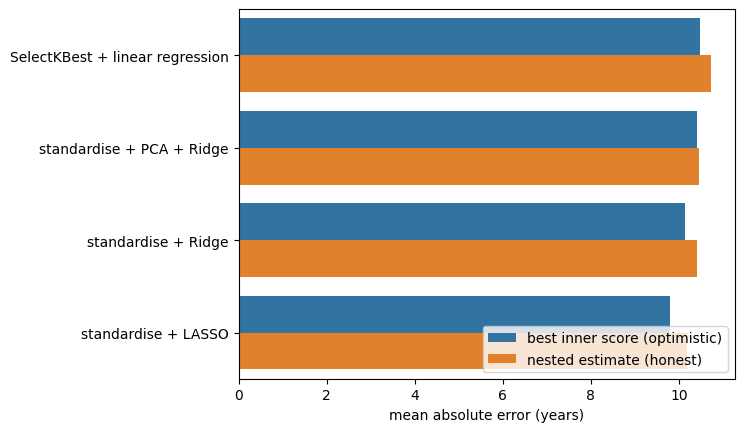

In [5]:
tidy = comparison.melt(id_vars='model',
                       value_vars=['best inner score (optimistic)', 'nested estimate (honest)'],
                       var_name='how it was scored', value_name='MAE')
ax = sns.barplot(data=tidy, y='model', x='MAE', hue='how it was scored')
plt.xlabel('mean absolute error (years)')
plt.ylabel('')
plt.legend(loc='lower right')
plt.show()

The optimism is real and points the same way for every model, but here it is a few tenths of a
year — nothing like the collapse we saw when feature selection escaped the loop. That is the
typical picture for a small grid on data containing genuine signal, and it is worth saying
plainly: nested cross-validation usually *confirms* your result rather than demolishing it.

Notice also that the ranking of the models is not quite the same in the two columns. LASSO looks
clearly best if you read the optimistic column, and merely joint-best once the estimates are
honest. Choosing between models by their optimistic scores is the same mistake one level up.

The reason to do it anyway is that you cannot know which case you are in without doing it. The
optimism grows with the number of choices, shrinks with sample size, and is largest exactly where
the signal is weakest — that is, in the situations where you are most likely to be fooled and
least able to tell.

```{note}
**When can you skip it?** If the hyperparameters were fixed in advance — from the literature, from
a previous study, from theory — there is nothing to nest, because no choice was made from this
data. This is one of the underrated advantages of preregistration. Likewise, if you have a
genuinely independent test set that you touch exactly once, at the end, the tuning can happen by
ordinary cross-validation within the training data.
```

## The cost

Nested cross-validation multiplies work: 5 outer folds × 5 inner folds × 20 grid points = 500
model fits. For linear models on a hundred participants this is seconds. For a deep network on
thousands of images it can be prohibitive, and the usual compromises are a single outer
train-test split instead of an outer loop, a randomised search
([`RandomizedSearchCV`](https://scikit-learn.org/stable/modules/grid_search.html#randomized-parameter-search))
instead of an exhaustive grid, or fewer, better-chosen hyperparameters.

What is not an acceptable compromise is reporting the inner score as if it were a performance
estimate.

## Where we stand

We can now state a complete, honest recipe for a predictive model:

1. Put every step that learns from data into a **pipeline**.
2. Tune the hyperparameters by **inner cross-validation**.
3. Estimate performance by an **outer cross-validation** wrapped around the whole of step 2.
4. **Finalise** by refitting the entire procedure — tuning included — on all available data.
5. Compare everything to a **baseline**, and report both.

That recipe is the technical core of this book. What it cannot tell you is whether the model will
work on the next scanner, in the next hospital, or for people unlike those in your sample — nor
whether the thing it has learned is the thing you think it has learned. Those questions belong to
[chapter 6](../6_validity/index.md) and [chapter 7](../7_model_explanation/index.md).

:::{admonition} Exercise 5.3
:class: tip, dropdown
Widen the grid for `standardise + Ridge` from 5 alphas to 30 (`np.logspace(-2, 5, 30)`). What
happens to the optimism?

:::{admonition} Solution
:class: note, dropdown
The optimism grows: more candidates means more chances for one of them to suit the validation
folds by luck. The nested estimate, meanwhile, barely moves — it is measuring the procedure, and
the procedure has not really improved. A wider grid is not free.
:::
:::

:::{admonition} Exercise 5.4
:class: tip, dropdown
Increase the sample from 100 to 400 participants and repeat the comparison. Which column changes
more, and why?

:::{admonition} Solution
:class: note, dropdown
Both improve, but the gap between them narrows sharply. With more participants each validation
fold is larger, so the inner comparison between hyperparameters is less noisy and the winner is
chosen for better reasons than luck. Optimism from selection is, at bottom, a small-sample
problem.
:::
:::

:::{admonition} Exercise 5.5
:class: tip, dropdown
Take your own dataset through all five steps of the recipe above. Report the baseline alongside
the result.
:::